# Matrix-Log Entropy of a Graph Laplacian

This notebook uses `matrix_log_entropy_workflow` to estimate an entropy-like spectral quantity for a small graph Laplacian. The graph has two densely connected communities joined by a weak bridge, so its normalized Laplacian spectrum contains both community-scale and global-connectivity information.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a graph-spectrum diagnostic built from a normalized Laplacian. Entropy-like functions of graph spectra appear in network comparison, diffusion diagnostics, covariance spectra, and regularized log-determinant studies.

**QSVT implementation.** The package workflow normalizes the positive semidefinite matrix, fits polynomials for `log(x + epsilon)` and `-x log(x + epsilon)`, applies them spectrally, and compares against dense reference matrix functions.

**Classical reference and quantum relevance.** The dense eigendecomposition validates the finite example. In a QSVT setting, the same polynomial log and entropy-density functions are transform cores once a block encoding of the graph operator and a readout strategy for traces or state expectations are supplied.

## Variable definitions

- `n_left`, `n_right`: sizes of the two graph communities.
- `bridge_weight`: edge weight joining the two communities.
- `adjacency`: weighted graph adjacency matrix.
- `laplacian`: combinatorial graph Laplacian.
- `density_laplacian`: trace-normalized positive semidefinite Laplacian.
- `epsilon`: log regularization parameter.
- `result`: package matrix-log entropy workflow result.
- `evals`: eigenvalues of `density_laplacian`.
- `entropy_density_exact`, `entropy_density_poly`: exact and polynomial entropy-density values on eigenvalues.
- `fig`, `axes`, and similar names are plotting helpers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.algorithms import matrix_log_entropy_workflow
from qsvt.polynomials import eval_polynomial
from qsvt.spectral import eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_left = 5
n_right = 5
bridge_weight = 0.35
n_vertices = n_left + n_right

adjacency = np.zeros((n_vertices, n_vertices), dtype=float)
for community in (range(n_left), range(n_left, n_vertices)):
    for i in community:
        for j in community:
            if i < j:
                adjacency[i, j] = 1.0
                adjacency[j, i] = 1.0
adjacency[n_left - 1, n_left] = bridge_weight
adjacency[n_left, n_left - 1] = bridge_weight

degrees = np.sum(adjacency, axis=1)
laplacian = np.diag(degrees) - adjacency
density_laplacian = laplacian / np.trace(laplacian)

epsilon = 0.02
result = matrix_log_entropy_workflow(
    density_laplacian,
    epsilon=epsilon,
    degree=24,
    num_points=1201,
)

evals, _ = eigh_hermitian(density_laplacian)
scaled_evals = np.linalg.eigvalsh(result.scaled_operator.matrix)
entropy_density_exact = -evals * np.log(evals + epsilon)
entropy_density_poly = eval_polynomial(result.entropy_coeffs, scaled_evals)

print(f"reference entropy: {result.reference_entropy:.6f}")
print(f"polynomial entropy: {result.polynomial_entropy:.6f}")
print(f"log operator relative error: {result.log_operator_relative_error:.3e}")
print(f"entropy operator relative error: {result.entropy_operator_relative_error:.3e}")

reference entropy: 1.938678
polynomial entropy: 1.938678
log operator relative error: 1.803e-08
entropy operator relative error: 4.289e-10


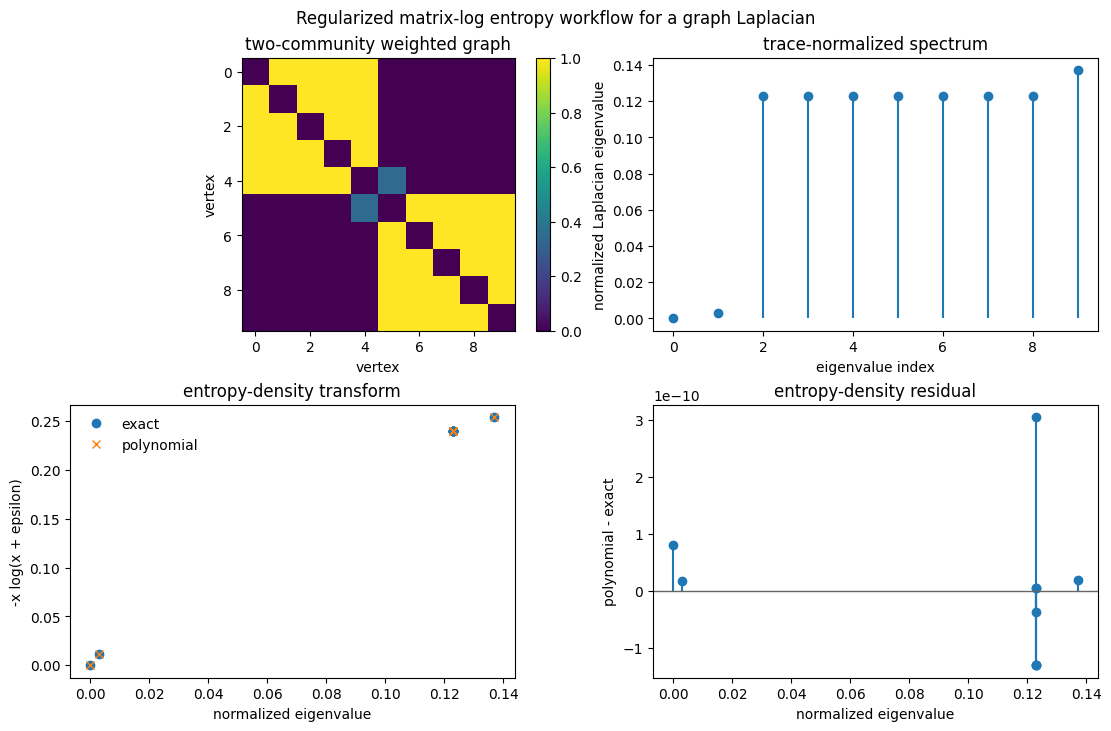

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), constrained_layout=True)

im = axes[0, 0].imshow(adjacency, cmap="viridis")
axes[0, 0].set_title("two-community weighted graph")
axes[0, 0].set_xlabel("vertex")
axes[0, 0].set_ylabel("vertex")
fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].stem(evals, basefmt=" ")
axes[0, 1].set_xlabel("eigenvalue index")
axes[0, 1].set_ylabel("normalized Laplacian eigenvalue")
axes[0, 1].set_title("trace-normalized spectrum")

axes[1, 0].plot(evals, entropy_density_exact, "o", label="exact")
axes[1, 0].plot(evals, entropy_density_poly, "x", label="polynomial")
axes[1, 0].set_xlabel("normalized eigenvalue")
axes[1, 0].set_ylabel("-x log(x + epsilon)")
axes[1, 0].set_title("entropy-density transform")
axes[1, 0].legend(frameon=False)

axes[1, 1].stem(evals, entropy_density_poly - entropy_density_exact, basefmt=" ")
axes[1, 1].axhline(0.0, color="0.4", linewidth=1.0)
axes[1, 1].set_xlabel("normalized eigenvalue")
axes[1, 1].set_ylabel("polynomial - exact")
axes[1, 1].set_title("entropy-density residual")

fig.suptitle("Regularized matrix-log entropy workflow for a graph Laplacian")
plt.show()

In [4]:
report = result.as_report()
assert report["mode"] == "matrix-log-entropy-workflow"
assert result.log_operator_relative_error < 1e-5
assert result.entropy_operator_relative_error < 1e-6
assert abs(result.polynomial_entropy - result.reference_entropy) < 1e-5

print(f"regularized_entropy: {result.reference_entropy:.6f}")
print(f"polynomial_entropy_error: {abs(result.polynomial_entropy - result.reference_entropy):.3e}")
print("validation: passed")

regularized_entropy: 1.938678
polynomial_entropy_error: 2.830e-11
validation: passed
